In [ ]:
import zipfile
from google.colab import drive
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
ZF = '/content/archive (2).zip'
ZR = zipfile.ZipFile(ZF, 'r')
ZR.extractall('/content/dataset')
ZR.close()

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

train_dir = '/content/dataset/Animals'
val_dir = '/content/dataset/Animals'
test_dir = '/content/dataset/Animals'
print("Classes: ", os.listdir(train_dir))

Classes:  ['dogs', 'cats', 'snakes']


In [ ]:
#data augmentation
train_G = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)
test_G = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
    )


In [ ]:
train_data = train_G.flow_from_directory(
    train_dir,
    target_size=(300, 300),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_G.flow_from_directory(
    val_dir,
    target_size=(300, 300),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2400 images belonging to 3 classes.
Found 600 images belonging to 3 classes.


In [ ]:

train_dog_list = os.listdir(os.path.join(train_dir, "dogs"))
train_cat_list = os.listdir(os.path.join(train_dir, "cats"))
train_snake_list = os.listdir(os.path.join(train_dir, "snakes"))


train_dog = os.path.join(train_dir, "dogs")
train_cat = os.path.join(train_dir, "cats")
train_snake = os.path.join(train_dir, "snakes")

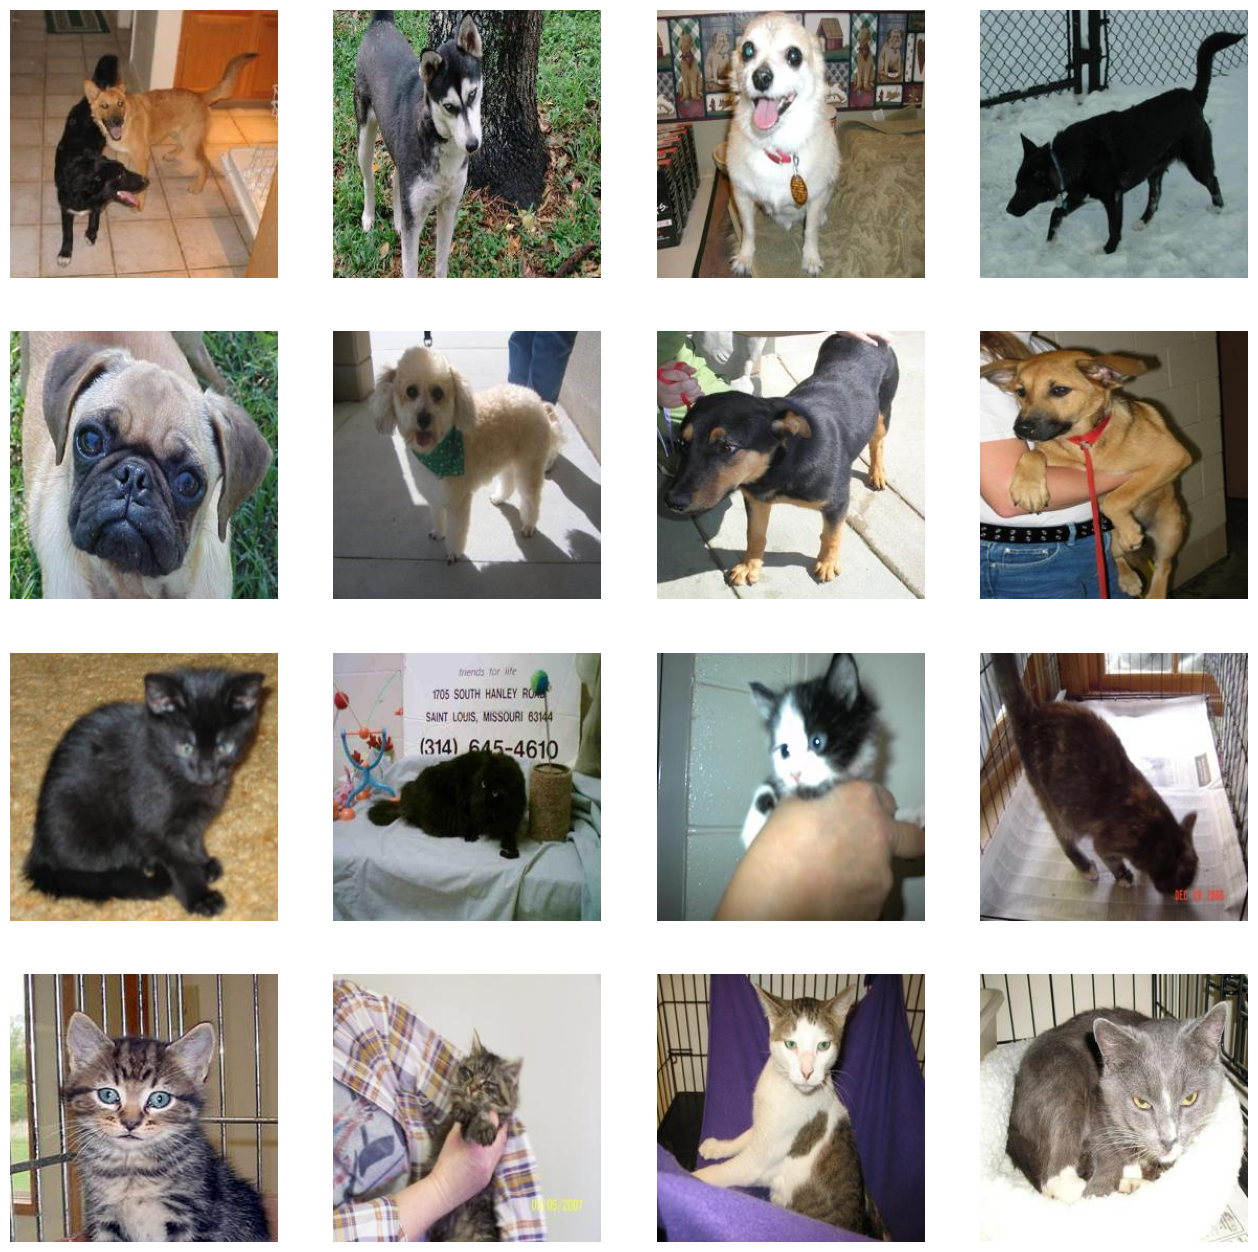

In [ ]:
nrows = 4
ncols = 4

pic_index = 0
pic_index += 8

next_dog_pix = [os.path.join(train_dog, fname)
               for fname in train_dog_list[pic_index-8:pic_index]]
next_cat_pix = [os.path.join(train_cat, fname)
               for fname in train_cat_list[pic_index-8:pic_index]]
next_snake_pix = [os.path.join(train_snake, fname)
               for fname in train_snake_list[pic_index-8:pic_index]]

images_to_plot = (next_dog_pix + next_cat_pix + next_snake_pix)[:nrows * ncols]

fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

for i, img_path in enumerate(images_to_plot):
    sp = plt.subplot(nrows, ncols, i + 1)
    sp.axis('Off')

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

In [ ]:

model_A = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(300, 300, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])


model_B = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(300, 300, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_A.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 298, 298, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 147, 147, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 170528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │    10,913,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,919,139 (41.65 MB)

 Trainable params: 10,919,139 (41.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_B.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 298, 298, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 147, 147, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 71, 71, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 35, 35, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 156800)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │    40,141,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,250,947 (153.55 MB)

 Trainable params: 40,250,947 (153.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

model_A.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

In [ ]:

model_B.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5)

mo_A = ModelCheckpoint('model_A.h5',monitor="val_loss",save_best_only=True)
mo_B = ModelCheckpoint('model_B.h5',monitor="val_loss", save_best_only=True)

In [ ]:
history_A = model_A.fit(
      train_data,
      epochs=15,
      verbose=1,
      validation_data = val_data,
      callbacks=[early_stop, mo_A]
       )

Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 266s 4s/step - accuracy: 0.6483 - loss: 0.7312 - val_accuracy: 0.6167 - val_loss: 0.8209
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6615 - loss: 0.7405

75/75 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.6615 - loss: 0.7404 - val_accuracy: 0.6683 - val_loss: 0.7561
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 283s 4s/step - accuracy: 0.6838 - loss: 0.7334 - val_accuracy: 0.6267 - val_loss: 0.7685
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6795 - loss: 0.6945

75/75 ━━━━━━━━━━━━━━━━━━━━ 303s 4s/step - accuracy: 0.6794 - loss: 0.6947 - val_accuracy: 0.6400 - val_loss: 0.7244
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 273s 4s/step - accuracy: 0.6635 - loss: 0.7148 - val_accuracy: 0.6383 - val_loss: 0.7599
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 265s 4s/step - accuracy: 0.6802 - loss: 0.6723 - val_accuracy: 0.6233 - val_loss: 0.7895
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 275s 4s/step - accuracy: 0.6668 - loss: 0.7025 - val_accuracy: 0.6667 - val_loss: 0.7267
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 313s 4s/step - accuracy: 0.6719 - loss: 0.7094 - val_accuracy: 0.6267 - val_loss: 0.7497
Epoch 9/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 276s 4s/step - accuracy: 0.6872 - loss: 0.6764 - val_accuracy: 0.6617 - val_loss: 0.7507


In [ ]:
history_B = model_B.fit(
      train_data,
      epochs=15,
      verbose=1,
      validation_data = val_data,
      callbacks=[early_stop, mo_B]
      )

Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5277 - loss: 0.9550

75/75 ━━━━━━━━━━━━━━━━━━━━ 613s 8s/step - accuracy: 0.5280 - loss: 0.9550 - val_accuracy: 0.5883 - val_loss: 0.8468
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6096 - loss: 0.8470

75/75 ━━━━━━━━━━━━━━━━━━━━ 673s 9s/step - accuracy: 0.6093 - loss: 0.8473 - val_accuracy: 0.5817 - val_loss: 0.8227
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 661s 9s/step - accuracy: 0.6245 - loss: 0.8150 - val_accuracy: 0.5983 - val_loss: 0.8239
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 609s 8s/step - accuracy: 0.6343 - loss: 0.7859 - val_accuracy: 0.5633 - val_loss: 0.8838
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6122 - loss: 0.7978

75/75 ━━━━━━━━━━━━━━━━━━━━ 648s 9s/step - accuracy: 0.6125 - loss: 0.7977 - val_accuracy: 0.6050 - val_loss: 0.8136
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6355 - loss: 0.7709

75/75 ━━━━━━━━━━━━━━━━━━━━ 612s 8s/step - accuracy: 0.6355 - loss: 0.7708 - val_accuracy: 0.6133 - val_loss: 0.7686
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 633s 8s/step - accuracy: 0.6512 - loss: 0.7425 - val_accuracy: 0.5800 - val_loss: 0.8056
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 622s 8s/step - accuracy: 0.6379 - loss: 0.7454 - val_accuracy: 0.6083 - val_loss: 0.8200
Epoch 9/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6513 - loss: 0.7457

75/75 ━━━━━━━━━━━━━━━━━━━━ 627s 8s/step - accuracy: 0.6514 - loss: 0.7457 - val_accuracy: 0.6467 - val_loss: 0.7348
Epoch 10/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 623s 8s/step - accuracy: 0.6681 - loss: 0.7232 - val_accuracy: 0.5333 - val_loss: 1.0870
Epoch 11/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6591 - loss: 0.7192

75/75 ━━━━━━━━━━━━━━━━━━━━ 622s 8s/step - accuracy: 0.6592 - loss: 0.7190 - val_accuracy: 0.6367 - val_loss: 0.7203
Epoch 12/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 647s 9s/step - accuracy: 0.6880 - loss: 0.6690 - val_accuracy: 0.6550 - val_loss: 0.7295
Epoch 13/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 618s 8s/step - accuracy: 0.6854 - loss: 0.6648 - val_accuracy: 0.5850 - val_loss: 0.8793
Epoch 14/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6925 - loss: 0.6732

75/75 ━━━━━━━━━━━━━━━━━━━━ 622s 8s/step - accuracy: 0.6926 - loss: 0.6731 - val_accuracy: 0.6650 - val_loss: 0.7136
Epoch 15/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6950 - loss: 0.6643

75/75 ━━━━━━━━━━━━━━━━━━━━ 660s 9s/step - accuracy: 0.6951 - loss: 0.6644 - val_accuracy: 0.6817 - val_loss: 0.6837


In [ ]:
#train with transfer learning

base = tf.keras.applications.MobileNetV2(input_shape=(300, 300, 3), include_top=False, weights='imagenet')

base.trainable = False

model_A_TL = tf.keras.models.Sequential([
    base,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])


model_A_TL.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(learning_rate=0.0005),
              metrics=['accuracy'])

/tmp/ipython-input-3368308816.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(input_shape=(300, 300, 3), include_top=False, weights='imagenet')


In [ ]:

base2 = tf.keras.applications.MobileNetV2(input_shape=(300, 300, 3), include_top=False, weights='imagenet')
base2.trainable = False

model_B_TL = tf.keras.models.Sequential([
    base2,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])


model_B_TL.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(learning_rate=0.0005),
              metrics=['accuracy'])

/tmp/ipython-input-3167706720.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base2 = tf.keras.applications.MobileNetV2(input_shape=(300, 300, 3), include_top=False, weights='imagenet')


In [ ]:
mo_A_TL = ModelCheckpoint('model_A_TL.h5',monitor="val_loss", save_best_only=True)
mo_B_TL = ModelCheckpoint('model_B_TL.h5',monitor="val_loss", save_best_only=True)
history_A_TL = model_A_TL.fit(
      train_data,
      epochs=15,
      verbose=1,
      validation_data = val_data,
      callbacks=[early_stop, mo_A_TL])

Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7778 - loss: 5.0386

75/75 ━━━━━━━━━━━━━━━━━━━━ 322s 4s/step - accuracy: 0.7792 - loss: 4.9967 - val_accuracy: 0.9617 - val_loss: 0.2834
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9506 - loss: 0.3555

75/75 ━━━━━━━━━━━━━━━━━━━━ 325s 4s/step - accuracy: 0.9506 - loss: 0.3556 - val_accuracy: 0.9433 - val_loss: 0.2676
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 310s 4s/step - accuracy: 0.9629 - loss: 0.2145 - val_accuracy: 0.9433 - val_loss: 0.2990
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 322s 4s/step - accuracy: 0.9588 - loss: 0.2275 - val_accuracy: 0.9317 - val_loss: 0.7340
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9642 - loss: 0.2314

75/75 ━━━━━━━━━━━━━━━━━━━━ 312s 4s/step - accuracy: 0.9641 - loss: 0.2314 - val_accuracy: 0.9633 - val_loss: 0.2263
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 332s 4s/step - accuracy: 0.9671 - loss: 0.1804 - val_accuracy: 0.9467 - val_loss: 0.3291
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 313s 4s/step - accuracy: 0.9639 - loss: 0.1593 - val_accuracy: 0.9700 - val_loss: 0.2281
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 327s 4s/step - accuracy: 0.9670 - loss: 0.1373 - val_accuracy: 0.9667 - val_loss: 0.2639
Epoch 9/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9750 - loss: 0.0986

75/75 ━━━━━━━━━━━━━━━━━━━━ 321s 4s/step - accuracy: 0.9750 - loss: 0.0985 - val_accuracy: 0.9800 - val_loss: 0.1403
Epoch 10/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 327s 4s/step - accuracy: 0.9759 - loss: 0.1035 - val_accuracy: 0.9600 - val_loss: 0.1638
Epoch 11/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9795 - loss: 0.0769

75/75 ━━━━━━━━━━━━━━━━━━━━ 329s 4s/step - accuracy: 0.9795 - loss: 0.0769 - val_accuracy: 0.9683 - val_loss: 0.1213
Epoch 12/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9797 - loss: 0.0572

75/75 ━━━━━━━━━━━━━━━━━━━━ 313s 4s/step - accuracy: 0.9796 - loss: 0.0575 - val_accuracy: 0.9750 - val_loss: 0.0822
Epoch 13/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 326s 4s/step - accuracy: 0.9807 - loss: 0.0753 - val_accuracy: 0.9617 - val_loss: 0.1492
Epoch 14/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 313s 4s/step - accuracy: 0.9804 - loss: 0.0521 - val_accuracy: 0.9567 - val_loss: 0.1621
Epoch 15/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 326s 4s/step - accuracy: 0.9670 - loss: 0.0909 - val_accuracy: 0.9683 - val_loss: 0.1352


In [ ]:
history_B_TL = model_B_TL.fit(
      train_data,
      epochs=15,
      verbose=1,
      validation_data = val_data,
      callbacks=[early_stop, mo_B_TL])

Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7737 - loss: 4.7227

75/75 ━━━━━━━━━━━━━━━━━━━━ 328s 4s/step - accuracy: 0.7750 - loss: 4.6872 - val_accuracy: 0.9367 - val_loss: 0.6213
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9380 - loss: 0.4829

75/75 ━━━━━━━━━━━━━━━━━━━━ 329s 4s/step - accuracy: 0.9381 - loss: 0.4821 - val_accuracy: 0.9433 - val_loss: 0.2819
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9579 - loss: 0.1638

75/75 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.9579 - loss: 0.1642 - val_accuracy: 0.9750 - val_loss: 0.2284
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9676 - loss: 0.1629

75/75 ━━━━━━━━━━━━━━━━━━━━ 327s 4s/step - accuracy: 0.9675 - loss: 0.1635 - val_accuracy: 0.9467 - val_loss: 0.2125
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9686 - loss: 0.1104

75/75 ━━━━━━━━━━━━━━━━━━━━ 317s 4s/step - accuracy: 0.9686 - loss: 0.1107 - val_accuracy: 0.9517 - val_loss: 0.1377
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 329s 4s/step - accuracy: 0.9624 - loss: 0.0982 - val_accuracy: 0.9600 - val_loss: 0.1767
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 382s 4s/step - accuracy: 0.9762 - loss: 0.0820 - val_accuracy: 0.9567 - val_loss: 0.3008
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 320s 4s/step - accuracy: 0.9740 - loss: 0.0957 - val_accuracy: 0.9567 - val_loss: 0.3280
Epoch 9/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 326s 4s/step - accuracy: 0.9714 - loss: 0.1475 - val_accuracy: 0.9500 - val_loss: 0.2458
Epoch 10/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 337s 5s/step - accuracy: 0.9759 - loss: 0.0847 - val_accuracy: 0.9500 - val_loss: 0.2562


In [ ]:

def history_plot(history, title):
  acc = history.history["accuracy"]
  val_acc = history.history["val_accuracy"]
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]

  epochs = range(len(acc))

  plt.plot(epochs, acc, "r", label="Training accuracy")
  plt.plot(epochs, val_acc, "b", label="Validation accuracy")
  plt.title(title + " Accuracy")
  plt.legend(loc=0)
  plt.figure()


  plt.plot(epochs, loss, "r", label="Training Loss")
  plt.plot(epochs, val_loss, "b", label="Validation Loss")
  plt.title(title + " Loss")
  plt.legend(loc=0)

  plt.figure()



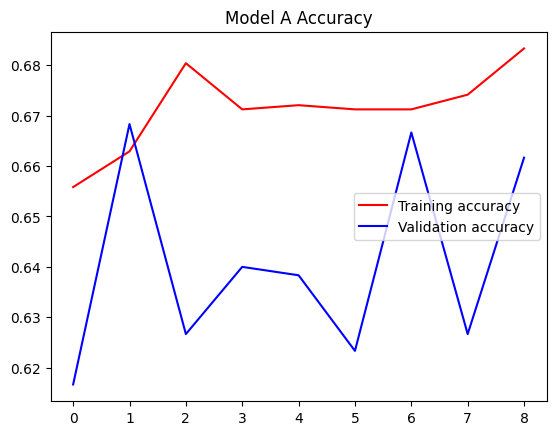

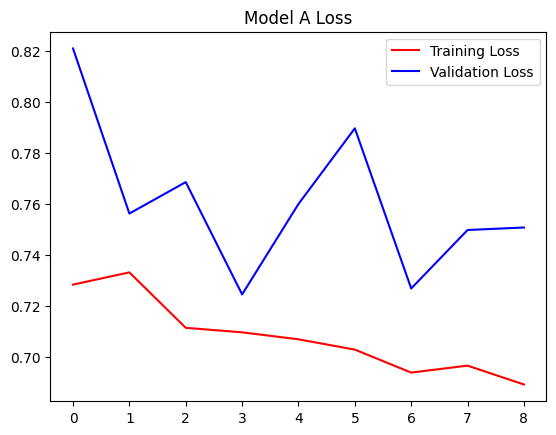

<Figure size 640x480 with 0 Axes>

In [ ]:
history_plot(history_A, "Model A")
plt.show()

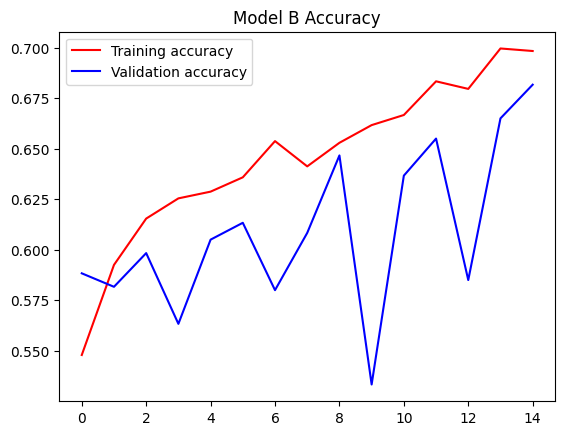

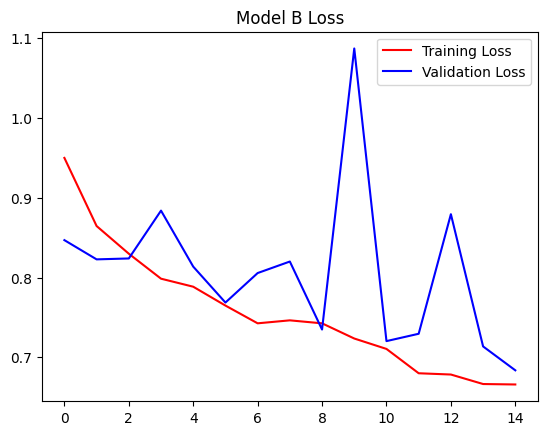

<Figure size 640x480 with 0 Axes>

In [ ]:
history_plot(history_B, "Model B")
plt.show()

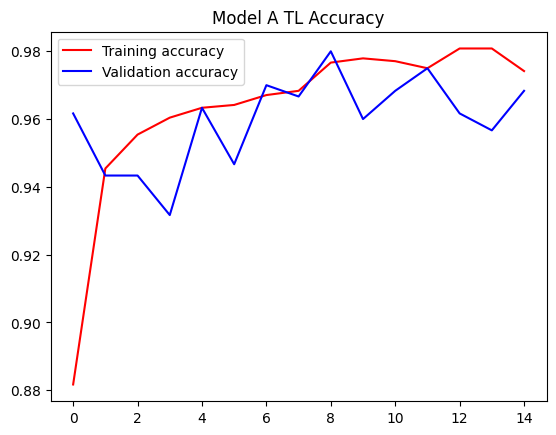

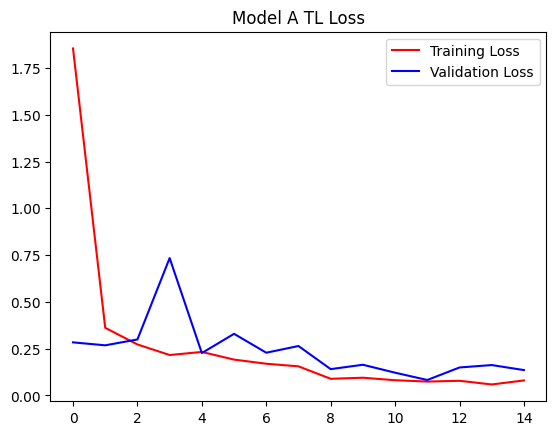

<Figure size 640x480 with 0 Axes>

In [ ]:
history_plot(history_A_TL, "Model A TL")
plt.show()

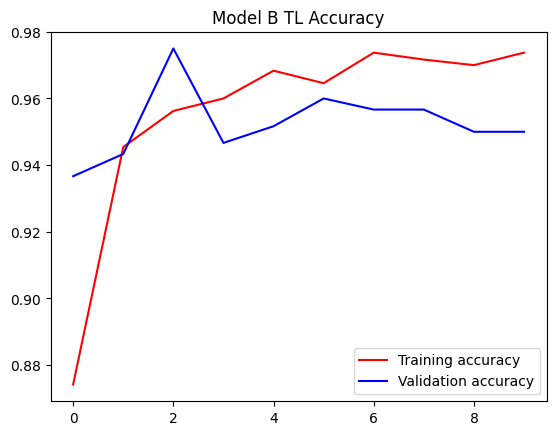

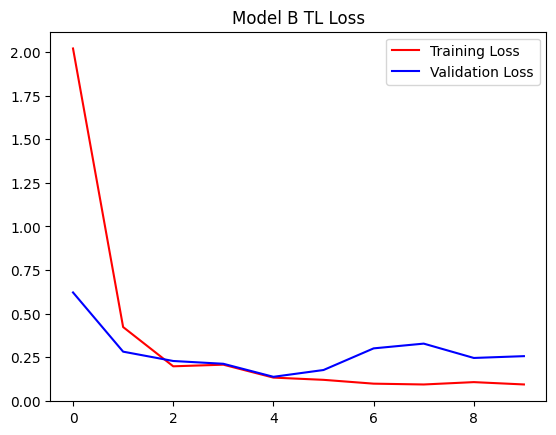

<Figure size 640x480 with 0 Axes>

In [ ]:
history_plot(history_B_TL, "Model B TL")
plt.show()